In [27]:
import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
#데이터 사이를 부드럽게 열결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt

df1 = pd.read_csv('greenData/resort/hotel.csv',encoding='utf-8-sig') # 호텔의 데이터
df2 = pd.read_csv('greenData/resort/reservation.csv',encoding='utf-8-sig') # 예약의 데이터
df3 = pd.read_csv('greenData/resort/room.csv',encoding='cp949') # 객실의 데이터
df4 = pd.read_csv('greenData/resort/member.csv',encoding='cp949') # 회원의 데이터


## 가장 인기 있는 호텔 국가별

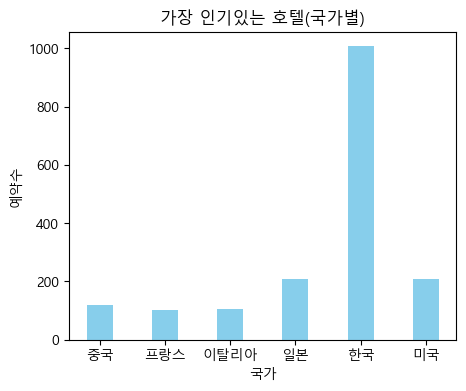

In [49]:
#merged = pd.merge(df1,df2,how='right',on='지역')

merged01 = pd.merge(df2,df3,how='inner',on='r_code')
merged02 = pd.merge(df1,merged01,how='inner',on='h_code')
list01 = merged02.groupby('country')['h_code'].count()

li01 = pd.DataFrame(list01)

#반드시 한글 깨짐 현상 코드를 삽입한다.

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

li01
#그래프 크기 지정 : figure(10,6)
plt.figure(figsize=(5,4))

country = ['중국','프랑스','이탈리아','일본','한국','미국']

for i in range(len(li01)):
    bars = plt.bar(country[i],li01['h_code'].iloc[i],width=0.4,color='skyblue')
    

plt.title("가장 인기있는 호텔(국가별)")
plt.xlabel("국가")
plt.ylabel("예약수")

plt.show()


## 가장 인기 있는 호텔 숙소유형별

type
Hotel         747
GuestHouse    328
Resort        315
Camping       186
Condo         173
Name: h_code, dtype: int64


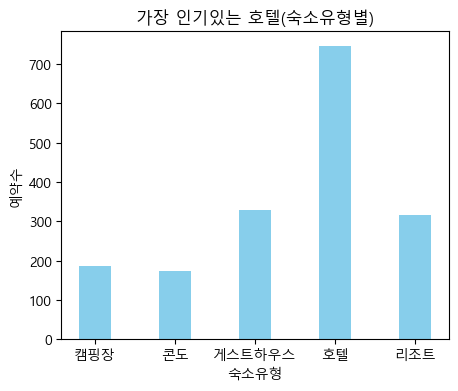

In [47]:
list02 = merged02.groupby('type')['h_code'].count()
print(list02.sort_values(ascending=False))

li02 = pd.DataFrame(list02)

#반드시 한글 깨짐 현상 코드를 삽입한다.

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

li01
#그래프 크기 지정 : figure(10,6)
plt.figure(figsize=(5,4))

type = ['캠핑장','콘도','게스트하우스','호텔','리조트']
for i in range(len(li02)):
    bars = plt.bar(type[i],li02['h_code'].iloc[i],width=0.4,color='skyblue')

plt.title("가장 인기있는 호텔(숙소유형별)")
plt.xlabel("숙소유형")
plt.ylabel("예약수")

plt.show()


## 인기있는 호텔 TOP10 성별별로

In [33]:

merged03 = pd.merge(df4,merged02,how='inner',on='m_code')


merged03

,m_code,m_email,m_pw,m_phone,m_birth,m_gender,m_nickName,m_coupon,m_regDate,m_is_deleted,...,original_price,discount_rate,coupon_used,final_price,cancel,cancel_date,review_status,roomName,price,maxOccupancy
0,1,user1@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000001,1988-04-12,1,user1,1,2025-10-01 12:49,0,...,328000,10,0,295200,0,NaN,1,슈페리얼 201호,164000,3
1,1,user1@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000001,1988-04-12,1,user1,1,2025-10-01 12:49,0,...,122000,10,0,109800,1,2025-10-02 8:20,0,디럭스 105호,122000,2
2,1,user1@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000001,1988-04-12,1,user1,1,2025-10-01 12:49,0,...,168000,10,0,151200,0,NaN,1,디럭스 301호,168000,3
3,1,user1@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000001,1988-04-12,1,user1,1,2025-10-01 12:49,0,...,232000,0,0,232000,0,NaN,1,스텐다드 305호,116000,2
4,1,user1@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000001,1988-04-12,1,user1,1,2025-10-01 12:49,0,...,131900,10,0,118710,0,NaN,1,골져스 202호,131900,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,296,user296@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000298,1996-10-10,0,nickname296,1,2026-03-01 12:49,0,...,178000,10,0,496800,0,NaN,1,슈페리얼 402호,178000,2
1495,297,user297@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000299,1979-11-11,1,nickname297,1,2026-03-01 12:49,0,...,107000,10,0,176400,0,NaN,1,슈페리얼 302호,107000,3
1496,298,user298@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000300,1983-12-12,0,nickname298,1,2026-03-01 12:49,0,...,124000,10,0,172800,1,2026-03-05 10:40,0,디럭스 101호,124000,3
1497,299,user299@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000301,2001-01-01,1,nickname299,1,2026-03-01 12:49,1,...,427200,0,0,427200,0,NaN,1,슈페리얼 505호,142400,4


## 회원 탈퇴 여부 (나이, 성별, 시기) - 가입일 ~ 탈퇴일 → 탈퇴일까지 걸리는 평균 시간 (y-시간 / x - 나이대,성별, 시기)

In [140]:
df4.loc[(df4['m_regDate']>='2025-10-01') & (df4['m_regDate']<'2025-11-01'),'가입한 월'] = '25년 10월'
df4.loc[(df4['m_regDate']>='2025-11-01') & (df4['m_regDate']<'2025-12-01'),'가입한 월'] = '25년 11월'
df4.loc[(df4['m_regDate']>='2025-12-01') & (df4['m_regDate']<'2026-01-01'),'가입한 월'] = '25년 12월'
df4.loc[(df4['m_regDate']>='2026-01-01') & (df4['m_regDate']<'2026-02-01'),'가입한 월'] = '26년 01월'
df4.loc[(df4['m_regDate']>='2026-02-01') & (df4['m_regDate']<'2026-03-01'),'가입한 월'] = '26년 02월'
df4.loc[(df4['m_regDate']>='2026-03-01') & (df4['m_regDate']<'2026-04-01'),'가입한 월'] = '26년 03월'

list05 = df4[df4['m_is_deleted']==1].copy() # df4의 복사본이라는 표시
list06 = df4[df4['m_is_deleted']==1].copy()
list07 = df4[df4['m_is_deleted']==1].copy()

list05.loc[(list05['m_birth']>='1966-01-01') & (list05['m_birth']<'1976-01-01'),'나이대'] = 50
list05.loc[(list05['m_birth']>='1976-01-01') & (list05['m_birth']<'1986-01-01'),'나이대'] = 40
list05.loc[(list05['m_birth']>='1986-01-01') & (list05['m_birth']<'1996-01-01'),'나이대'] = 30
list05.loc[(list05['m_birth']>='1996-01-01') & (list05['m_birth']<'2006-01-01'),'나이대'] = 20


li05 = list05.groupby('가입한 월').size().to_frame('탈퇴한인원')
li05 = pd.DataFrame(li05)


list06.loc[list06['m_gender']==0,'성별'] = '남성'
list06.loc[list06['m_gender']==1,'성별'] = '여성'

list06
li06 = list06.groupby('성별').size().to_frame('탈퇴한인원')
li06 =pd.DataFrame(li06)
li06




list07
li07 = list07.groupby('가입한 월').size().to_frame('탈퇴한인원')
li07 = pd.DataFrame(li07)
result20 = list05[list05['나이대']==20]
result20.groupby('가입한 월').size().to_frame('탈퇴한인원')

res

,m_code,m_email,m_pw,m_phone,m_birth,m_gender,m_nickName,m_coupon,m_regDate,m_is_deleted,deleted_at,가입한 월,탈퇴한 월,나이대
11,12,user12@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000012,2002-10-03,1,user12,1,2025-10-01 12:49,1,2026-02-26 12:49,25년 10월,26년 02월,20.0
52,53,user53@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000053,2002-11-03,1,user53,1,2025-11-01 12:49,1,2026-03-08 12:49,25년 11월,26년 03월,20.0
70,71,user71@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000071,2003-04-11,1,user71,1,2025-11-01 12:49,1,2026-03-05 12:49,25년 11월,26년 03월,20.0
94,95,user95@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000095,2001-07-02,1,user95,1,2025-12-01 12:49,1,2026-02-21 12:49,25년 12월,26년 02월,20.0
122,123,user123@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000125,2005-02-02,1,nickname123,1,2025-12-01 12:49,1,2026-03-13 12:49,25년 12월,26년 03월,20.0
204,205,user205@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000207,1999-12-25,0,nickname205,1,2026-01-01 12:49,1,2026-03-20 12:49,26년 01월,26년 03월,20.0
211,212,user212@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000214,1996-02-02,1,nickname212,1,2026-02-01 12:49,1,2026-03-18 12:49,26년 02월,26년 03월,20.0
298,299,user299@naver.com,$2a$10$xc9fFZ1MS.KLxzswXTT0.un8brEmJr0XCjCj4Zo...,1000000301,2001-01-01,1,nickname299,1,2026-03-01 12:49,1,2026-03-18 12:49,26년 03월,26년 03월,20.0


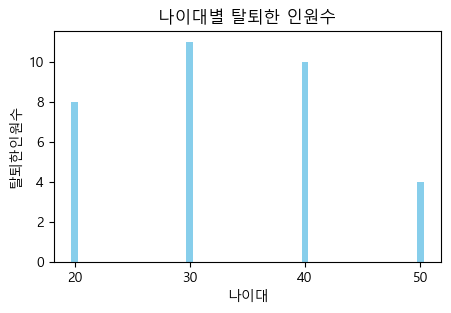

Index([20.0, 30.0, 40.0, 50.0], dtype='float64', name='나이대')


In [87]:
import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
#데이터 사이를 부드럽게 열결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5,3))

#plt.plot(li05.index,li05['탈퇴한인원'],color='skyblue',marker='o',markersize=10)
plt.bar(li05.index,li05['탈퇴한인원'],color='skyblue',width=0.4)

plt.xticks(li05.index)

plt.title('나이대별 탈퇴한 인원수')
plt.xlabel('나이대')
plt.ylabel('탈퇴한인원수')

plt.show()
print(li05.index)


In [136]:
import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
#데이터 사이를 부드럽게 열결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

result_G = list06[list06['성별']=='여성'].copy()
re_G = result_G.groupby('가입한 월').size().to_frame('탈퇴한인원')
result_M = list06[list06['성별']=='남성'].copy()
re_M = result_M.groupby('가입한 월').size().to_frame('탈퇴한인원')



plt.figure(figsize=(5,3))

plt.plot(re_G.index,re_G['탈퇴한인원'],color='skyblue',marker='o',label='여성')

plt.title('성별별 탈퇴한 인원수')
plt.xlabel('xkd')
plt.ylabel('탈퇴한인원수')
plt.legend()

plt.show()

,탈퇴한인원
가입한 월,
25년 10월,4
25년 11월,3
25년 12월,7
26년 01월,2
26년 02월,1
26년 03월,2


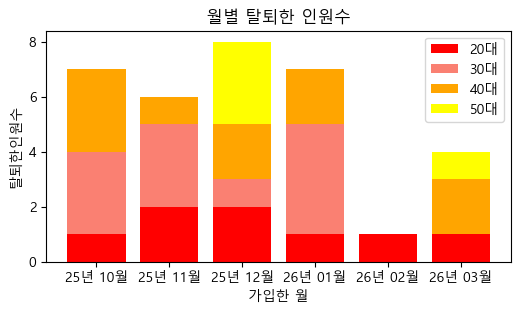

In [141]:
import pandas as pd
# matplotlib 매트플롯립도 반드시 import해서 사용한다.
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
#데이터 사이를 부드럽게 열결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

result20 = list05[list05['나이대']==20].copy()
re20 = result20.groupby('가입한 월').size().to_frame('탈퇴한인원')
result30 = list05[list05['나이대']==30].copy()
re30 = result30.groupby('가입한 월').size().to_frame('탈퇴한인원')
result40 = list05[list05['나이대']==40].copy()
re40 = result40.groupby('가입한 월').size().to_frame('탈퇴한인원')
result50 = list05[list05['나이대']==50].copy()
re50 = result50.groupby('가입한 월').size().to_frame('탈퇴한인원')

re30 = re30.reindex(re20.index, fill_value=0)
re40 = re40.reindex(re20.index, fill_value=0)
re50 = re50.reindex(re20.index, fill_value=0)



plt.figure(figsize=(6,3))
# 
plt.bar(li07.index,li07['탈퇴한인원'],color='skyblue')
plt.bar(re20.index,re20['탈퇴한인원'],color='red',label='20대')
plt.bar(re30.index,re30['탈퇴한인원'],color='salmon',label='30대',bottom= re20['탈퇴한인원'])
plt.bar(re40.index,re40['탈퇴한인원'],color='orange',label='40대',bottom= re20['탈퇴한인원']+re30['탈퇴한인원'])
plt.bar(re50.index,re50['탈퇴한인원'],color='yellow',label='50대',bottom= re20['탈퇴한인원']+re30['탈퇴한인원']+re40['탈퇴한인원'])

plt.title('월별 탈퇴한 인원수')
plt.xlabel('가입한 월')
plt.ylabel('탈퇴한인원수')

plt.legend()

plt.show()